In [48]:
from pathlib import Path 
import sys
import ProbabilisticParcellation.util as ut
import ProbabilisticParcellation.individ_group as ig
import ProbabilisticParcellation.plot as ppp
import matplotlib.pyplot as plt
import seaborn as sb
import pandas as pd
import numpy as np
import scipy.stats as ss
import IndividualParcellation.scripts.paths as paths




## Individual vs. group analysis

To reproduce results, run evaluate_mdtb_rest in scripts.rest.evaluation

In [50]:
base_dir = paths.set_base_dir() 
results_dir = paths.set_results_dir(base_dir)
data_dir = paths.set_fusion_dir(base_dir)
Data_Net = pd.read_csv(results_dir + '/evaluation/eval_dcbc_dtype-Net67Run_all_modeltypes_regionwise.tsv', sep='\t')
Data_Fus = pd.read_csv(results_dir + '/evaluation/eval_dcbc_dtype-Fus06Run_all_modeltypes_regionwise.tsv', sep='\t')

In [60]:
T = pd.read_csv(f'{data_dir}/MDTB/participants.tsv', delimiter='\t')
participants = T.participant_id
rest_subjects = participants[T['ses-rest'] == 1].tolist()

In [ ]:
Data_Net.head()

,Unnamed: 0,test_data,group_type,indivtrain_ind,indivtrain_val,indivtest_val,subj_num,dcbc_group,dcbc_indiv,dcbc_data,type
0,0,MDTB,Models_03,half,1,2,0,0.098408,0.002700,0.000066,general_general
1,1,MDTB,Models_03,half,1,2,1,0.072834,0.072876,0.047621,general_general
2,2,MDTB,Models_03,half,1,2,2,0.174181,0.062534,0.054103,general_general
3,3,MDTB,Models_03,half,1,2,3,0.079955,0.052171,0.048160,general_general
4,4,MDTB,Models_03,half,1,2,4,0.166299,0.075974,0.058808,general_general


In [ ]:
Data_Fus.head()

,Unnamed: 0,test_data,group_type,indivtrain_ind,indivtrain_val,indivtest_val,subj_num,mask,dcbc_group,dcbc_indiv,dcbc_data,mtype
0,0,MDTB,Models_03,half,1,2,0,motor,0.034695,0.023870,0.015591,general_general
1,1,MDTB,Models_03,half,1,2,1,motor,0.050137,0.024399,0.019694,general_general
2,2,MDTB,Models_03,half,1,2,2,motor,0.033624,-0.000270,0.001879,general_general
3,3,MDTB,Models_03,half,1,2,3,motor,0.003350,-0.017110,0.007746,general_general
4,4,MDTB,Models_03,half,1,2,4,motor,0.056412,0.015074,0.001359,general_general


In [52]:
# Melt dataframe to have dcbc_group, dcbc_indiv and dcbc_data as a single column
Data_Net = pd.melt(Data_Net, value_vars=['dcbc_group', 'dcbc_indiv', 'dcbc_data'], var_name='criterion', value_name='DCBC', id_vars=['mtype', 'subj_num', 'mask'])
Data_Fus = pd.melt(Data_Fus, value_vars=['dcbc_group', 'dcbc_indiv', 'dcbc_data'], var_name='criterion', value_name='DCBC', id_vars=['mtype', 'subj_num', 'mask'])

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'general_general'),
  Text(1, 0, 'general_general_eq'),
  Text(2, 0, 'general_subject_specific'),
  Text(3, 0, 'general_subject_specific_eq'),
  Text(4, 0, 'subject_specific_general'),
  Text(5, 0, 'subject_specific_general_eq'),
  Text(6, 0, 'subject_specific_subject_specific'),
  Text(7, 0, 'subject_specific_subject_specific_eq')])

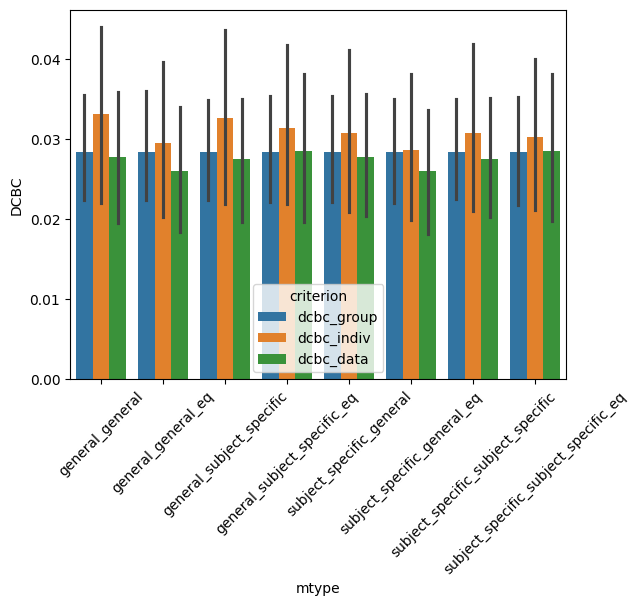

In [68]:
# Seaborn barplot
sb.barplot(x='mtype', y='DCBC',hue='criterion', data=Data_Net[Data_Net['mask'] == 'demand'])
# rotate x-axis labels
plt.xticks(rotation=45)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'general_general'),
  Text(1, 0, 'general_general_eq'),
  Text(2, 0, 'general_subject_specific'),
  Text(3, 0, 'general_subject_specific_eq'),
  Text(4, 0, 'subject_specific_general'),
  Text(5, 0, 'subject_specific_general_eq'),
  Text(6, 0, 'subject_specific_subject_specific'),
  Text(7, 0, 'subject_specific_subject_specific_eq')])

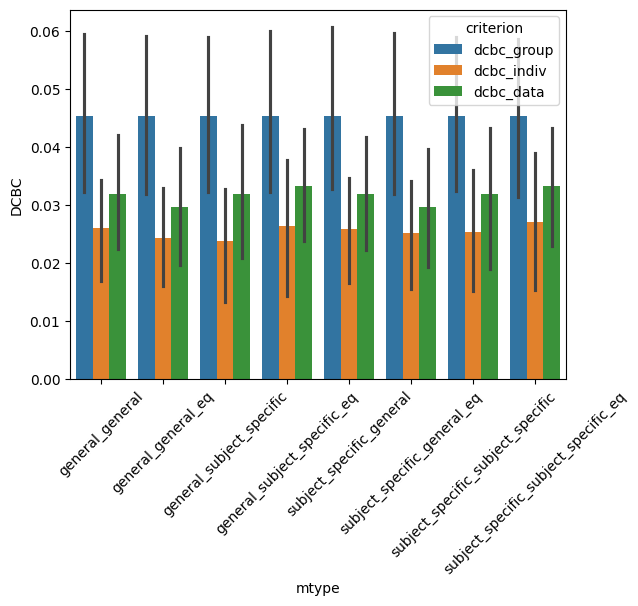

In [63]:
# Seaborn barplot
sb.barplot(x='mtype', y='DCBC',hue='criterion', data=Data_Fus[Data_Fus['mask'] == 'sls'])
# rotate x-axis labels
plt.xticks(rotation=45)


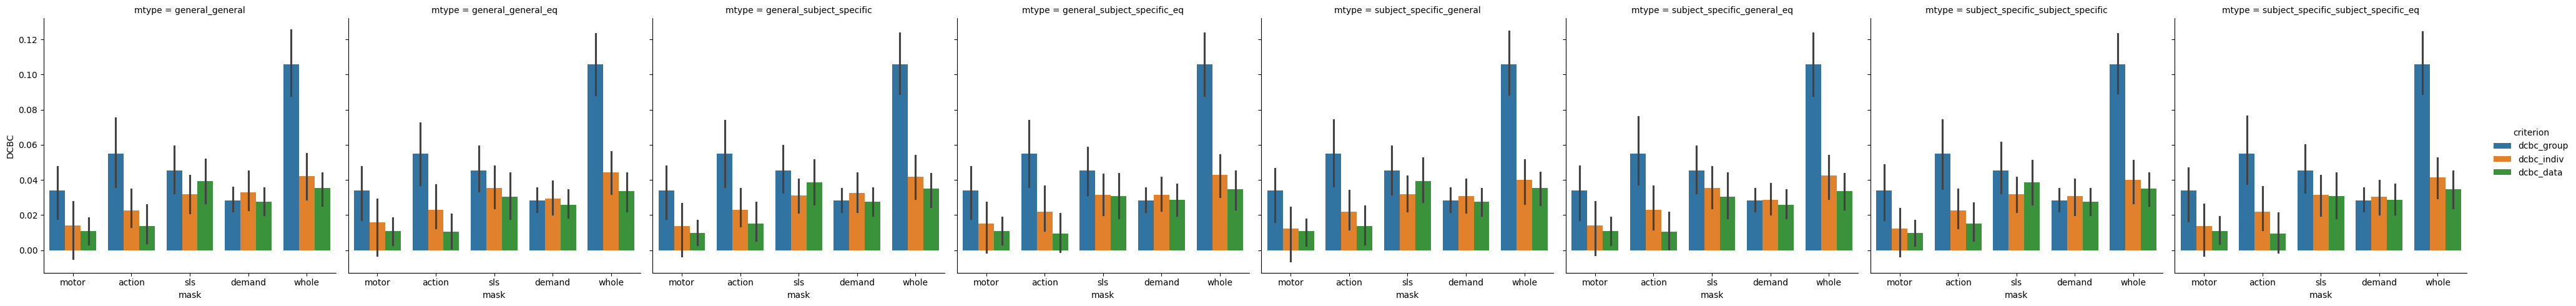

In [72]:
sb.catplot(x='mask', y='DCBC', col='mtype', hue='criterion', data=Data_Net, kind='bar')
# plt.xticks(ticks=range(len(rest_subjects)), labels=rest_subjects, rotation=45)


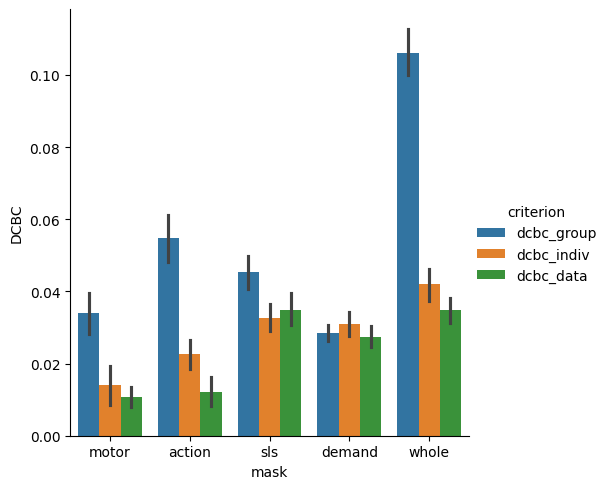

In [73]:
sb.catplot(x='mask', y='DCBC', hue='criterion', data=Data_Net, kind='bar')


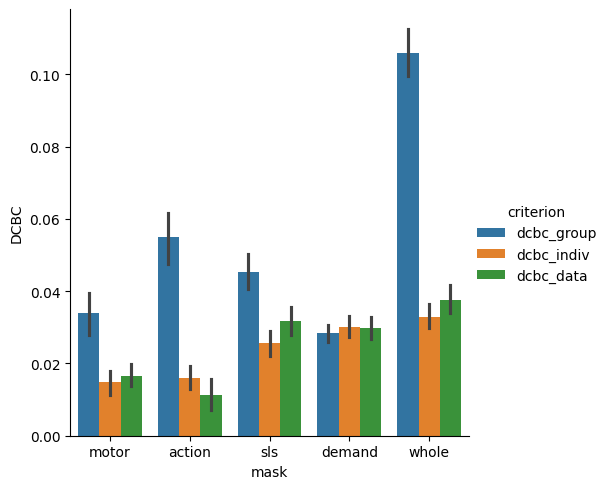

In [74]:
sb.catplot(x='mask', y='DCBC', hue='criterion', data=Data_Fus, kind='bar')


([<matplotlib.axis.XTick at 0x16cdccd60>,
 [Text(0, 0, 'sub-02'),
  Text(1, 0, 'sub-03'),
  Text(2, 0, 'sub-06'),
  Text(3, 0, 'sub-08'),
  Text(4, 0, 'sub-10'),
  Text(5, 0, 'sub-12'),
  Text(6, 0, 'sub-14'),
  Text(7, 0, 'sub-18'),
  Text(8, 0, 'sub-20'),
  Text(9, 0, 'sub-22'),
  Text(10, 0, 'sub-24'),
  Text(11, 0, 'sub-25'),
  Text(12, 0, 'sub-26'),
  Text(13, 0, 'sub-27'),
  Text(14, 0, 'sub-28'),
  Text(15, 0, 'sub-30'),
  Text(16, 0, 'sub-31')])

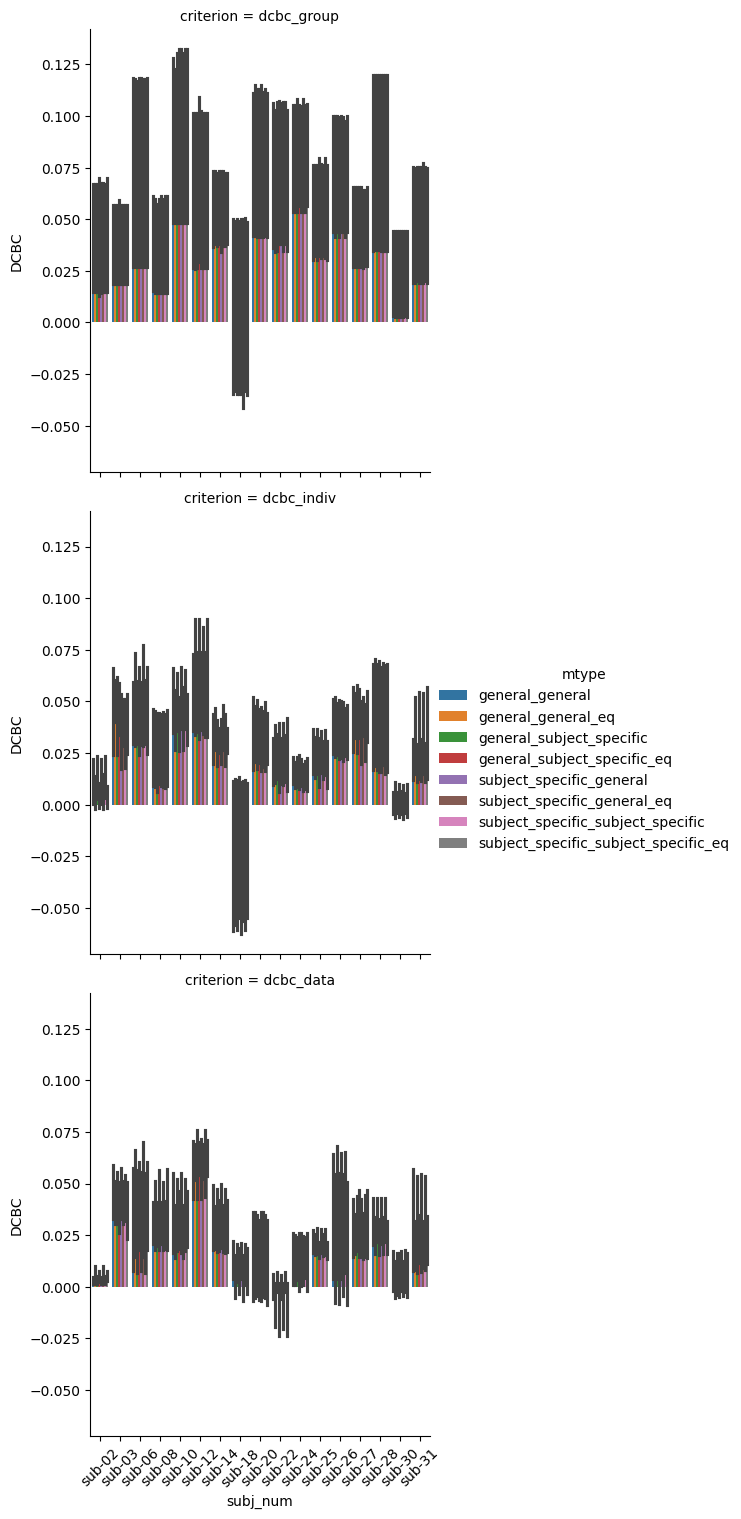

In [69]:
sb.catplot(x='subj_num', y='DCBC', row='criterion', hue='mtype', data=Data_Net, kind='bar')
plt.xticks(ticks=range(len(rest_subjects)), labels=rest_subjects, rotation=45)


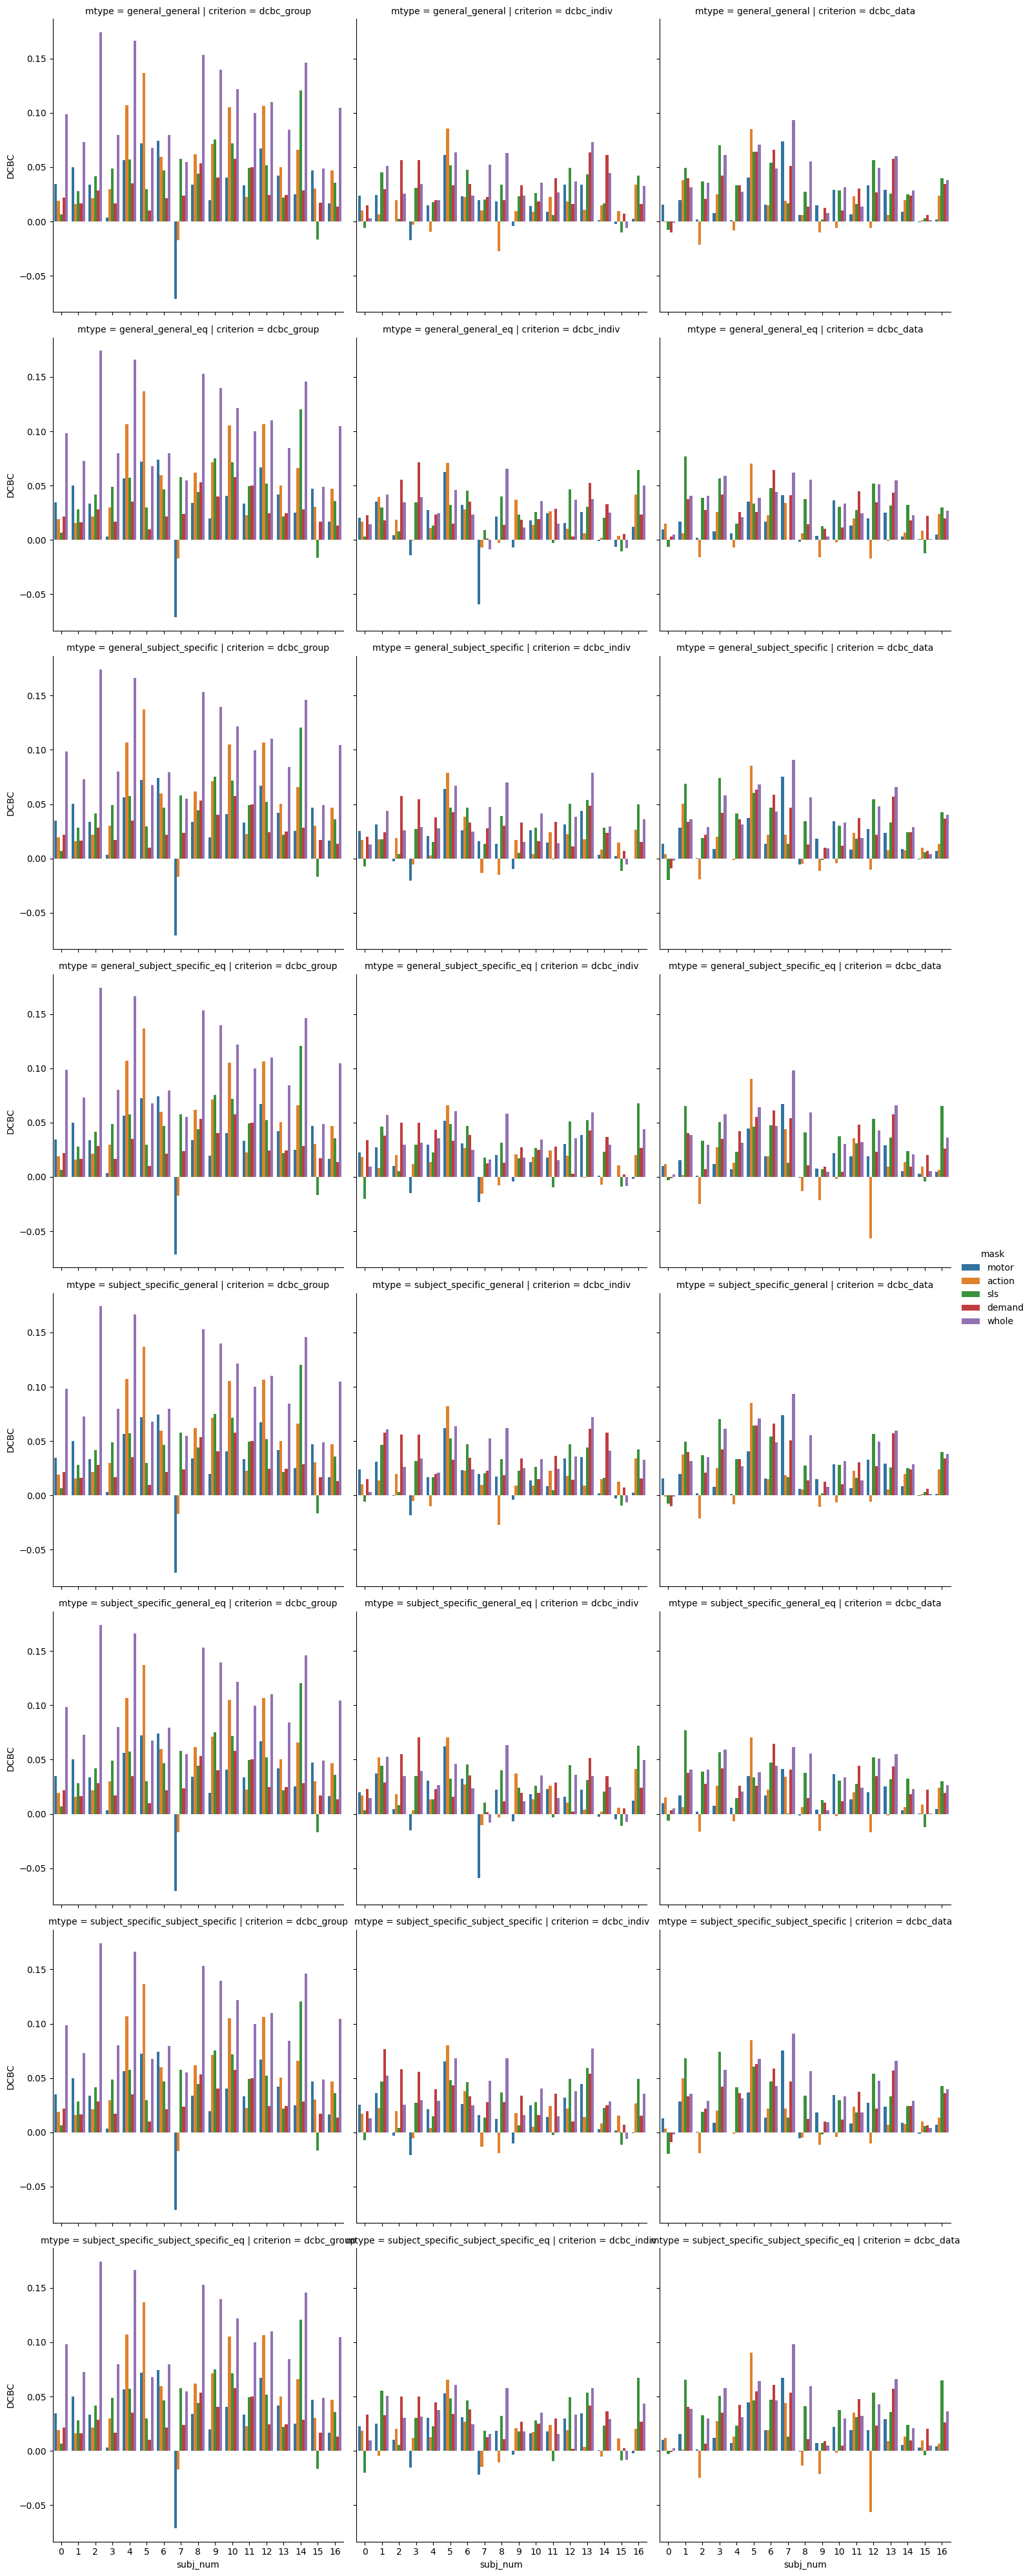

In [36]:
sb.catplot(x='subj_num', y='DCBC', row='mtype', col='criterion', hue='mask', data=Data_Fus, kind='bar')
# plt.xticks(ticks=range(len(rest_subjects)), labels=rest_subjects, rotation=45)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'general_general'),
  Text(1, 0, 'general_general_eq'),
  Text(2, 0, 'general_subject_specific'),
  Text(3, 0, 'general_subject_specific_eq'),
  Text(4, 0, 'subject_specific_general'),
  Text(5, 0, 'subject_specific_general_eq'),
  Text(6, 0, 'subject_specific_subject_specific'),
  Text(7, 0, 'subject_specific_subject_specific_eq')])

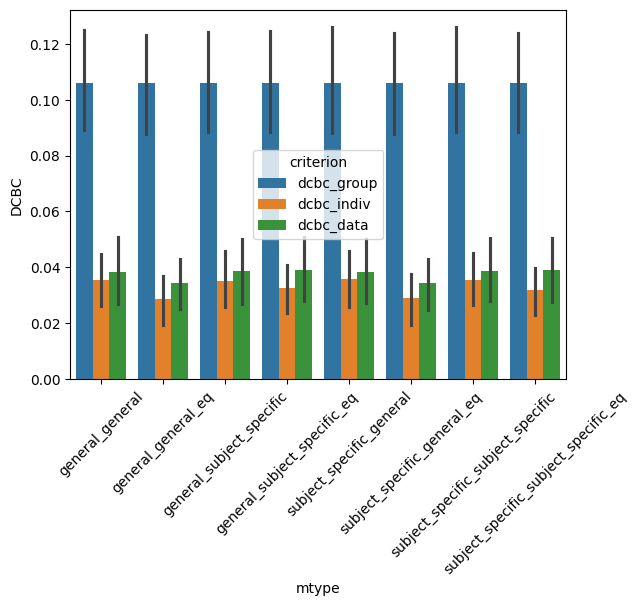

In [43]:
# Seaborn barplot
sb.barplot(x='mtype', y='DCBC',hue='criterion', data=Data_Fus[Data_Fus['mask'] == 'whole'])
# rotate x-axis labels
plt.xticks(rotation=45)


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'general_general'),
  Text(1, 0, 'general_general_eq'),
  Text(2, 0, 'general_subject_specific'),
  Text(3, 0, 'general_subject_specific_eq'),
  Text(4, 0, 'subject_specific_general'),
  Text(5, 0, 'subject_specific_general_eq'),
  Text(6, 0, 'subject_specific_subject_specific'),
  Text(7, 0, 'subject_specific_subject_specific_eq')])

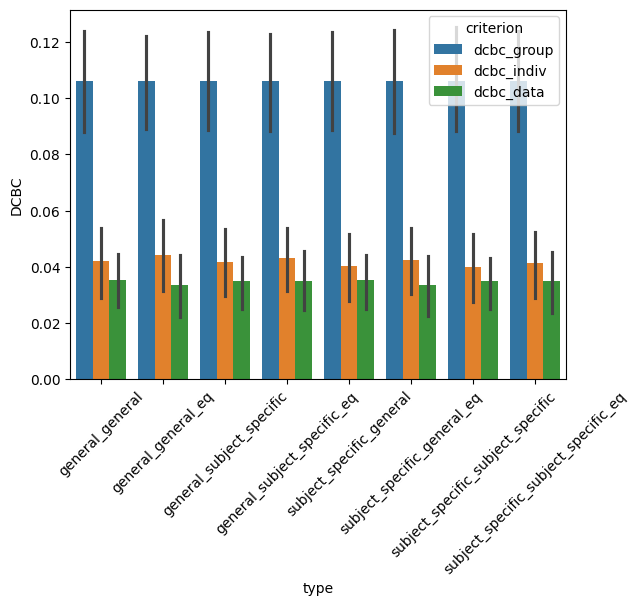

In [44]:
# Seaborn barplot
sb.barplot(x='type', y='DCBC',hue='criterion', data=Data_melt)
# rotate x-axis labels
plt.xticks(rotation=45)


In [42]:
Data_Fus

,mtype,subj_num,mask,criterion,DCBC
0,general_general,0,motor,dcbc_group,0.034695
1,general_general,1,motor,dcbc_group,0.050137
2,general_general,2,motor,dcbc_group,0.033624
3,general_general,3,motor,dcbc_group,0.003350
4,general_general,4,motor,dcbc_group,0.056412
...,...,...,...,...,...
2035,subject_specific_subject_specific_eq,12,whole,dcbc_data,0.042838
2036,subject_specific_subject_specific_eq,13,whole,dcbc_data,0.065979
2037,subject_specific_subject_specific_eq,14,whole,dcbc_data,0.020858
2038,subject_specific_subject_specific_eq,15,whole,dcbc_data,0.005130
